# Load the dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
df=pd.read_csv('Metro_Interstate_Traffic_Volume.csv')
df

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918
...,...,...,...,...,...,...,...,...,...
48199,NaN,283.45,0.0,0.0,75,Clouds,broken clouds,2018-09-30 19:00:00,3543
48200,NaN,282.76,0.0,0.0,90,Clouds,overcast clouds,2018-09-30 20:00:00,2781
48201,NaN,282.73,0.0,0.0,90,Thunderstorm,proximity thunderstorm,2018-09-30 21:00:00,2159
48202,NaN,282.09,0.0,0.0,90,Clouds,overcast clouds,2018-09-30 22:00:00,1450


In [3]:
df.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   holiday              61 non-null     object 
 1   temp                 48204 non-null  float64
 2   rain_1h              48204 non-null  float64
 3   snow_1h              48204 non-null  float64
 4   clouds_all           48204 non-null  int64  
 5   weather_main         48204 non-null  object 
 6   weather_description  48204 non-null  object 
 7   date_time            48204 non-null  object 
 8   traffic_volume       48204 non-null  int64  
dtypes: float64(3), int64(2), object(4)
memory usage: 3.3+ MB


In [5]:
df.describe()

,temp,rain_1h,snow_1h,clouds_all,traffic_volume
count,48204.000000,48204.000000,48204.000000,48204.000000,48204.000000
mean,281.205870,0.334264,0.000222,49.362231,3259.818355
std,13.338232,44.789133,0.008168,39.015750,1986.860670
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,272.160000,0.000000,0.000000,1.000000,1193.000000
50%,282.450000,0.000000,0.000000,64.000000,3380.000000
75%,291.806000,0.000000,0.000000,90.000000,4933.000000
max,310.070000,9831.300000,0.510000,100.000000,7280.000000


In [6]:
df.shape

(48204, 9)

# Missing Values

In [7]:
df.isnull().sum()

holiday                48143
temp                       0
rain_1h                    0
snow_1h                    0
clouds_all                 0
weather_main               0
weather_description        0
date_time                  0
traffic_volume             0
dtype: int64

In [8]:
df['holiday']=df['holiday'].apply(lambda x: 0 if x=='None' else 1)

In [9]:
df.isnull().sum()

holiday                0
temp                   0
rain_1h                0
snow_1h                0
clouds_all             0
weather_main           0
weather_description    0
date_time              0
traffic_volume         0
dtype: int64

# Converting date-time

In [10]:
df['date_time']=pd.to_datetime(df['date_time'])

In [11]:
df

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,1,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,1,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,1,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,1,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,1,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918
...,...,...,...,...,...,...,...,...,...
48199,1,283.45,0.0,0.0,75,Clouds,broken clouds,2018-09-30 19:00:00,3543
48200,1,282.76,0.0,0.0,90,Clouds,overcast clouds,2018-09-30 20:00:00,2781
48201,1,282.73,0.0,0.0,90,Thunderstorm,proximity thunderstorm,2018-09-30 21:00:00,2159
48202,1,282.09,0.0,0.0,90,Clouds,overcast clouds,2018-09-30 22:00:00,1450


# Feature Enginnering

In [12]:
df['hour']=df['date_time'].dt.hour
df['day']=df['date_time'].dt.dayofweek

In [13]:
df.shape

(48204, 11)

In [14]:
df

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume,hour,day
0,1,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545,9,1
1,1,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516,10,1
2,1,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767,11,1
3,1,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026,12,1
4,1,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918,13,1
...,...,...,...,...,...,...,...,...,...,...,...
48199,1,283.45,0.0,0.0,75,Clouds,broken clouds,2018-09-30 19:00:00,3543,19,6
48200,1,282.76,0.0,0.0,90,Clouds,overcast clouds,2018-09-30 20:00:00,2781,20,6
48201,1,282.73,0.0,0.0,90,Thunderstorm,proximity thunderstorm,2018-09-30 21:00:00,2159,21,6
48202,1,282.09,0.0,0.0,90,Clouds,overcast clouds,2018-09-30 22:00:00,1450,22,6


# Selecting Important Features

In [15]:
features=df[['traffic_volume','temp','rain_1h','snow_1h','clouds_all','hour']]

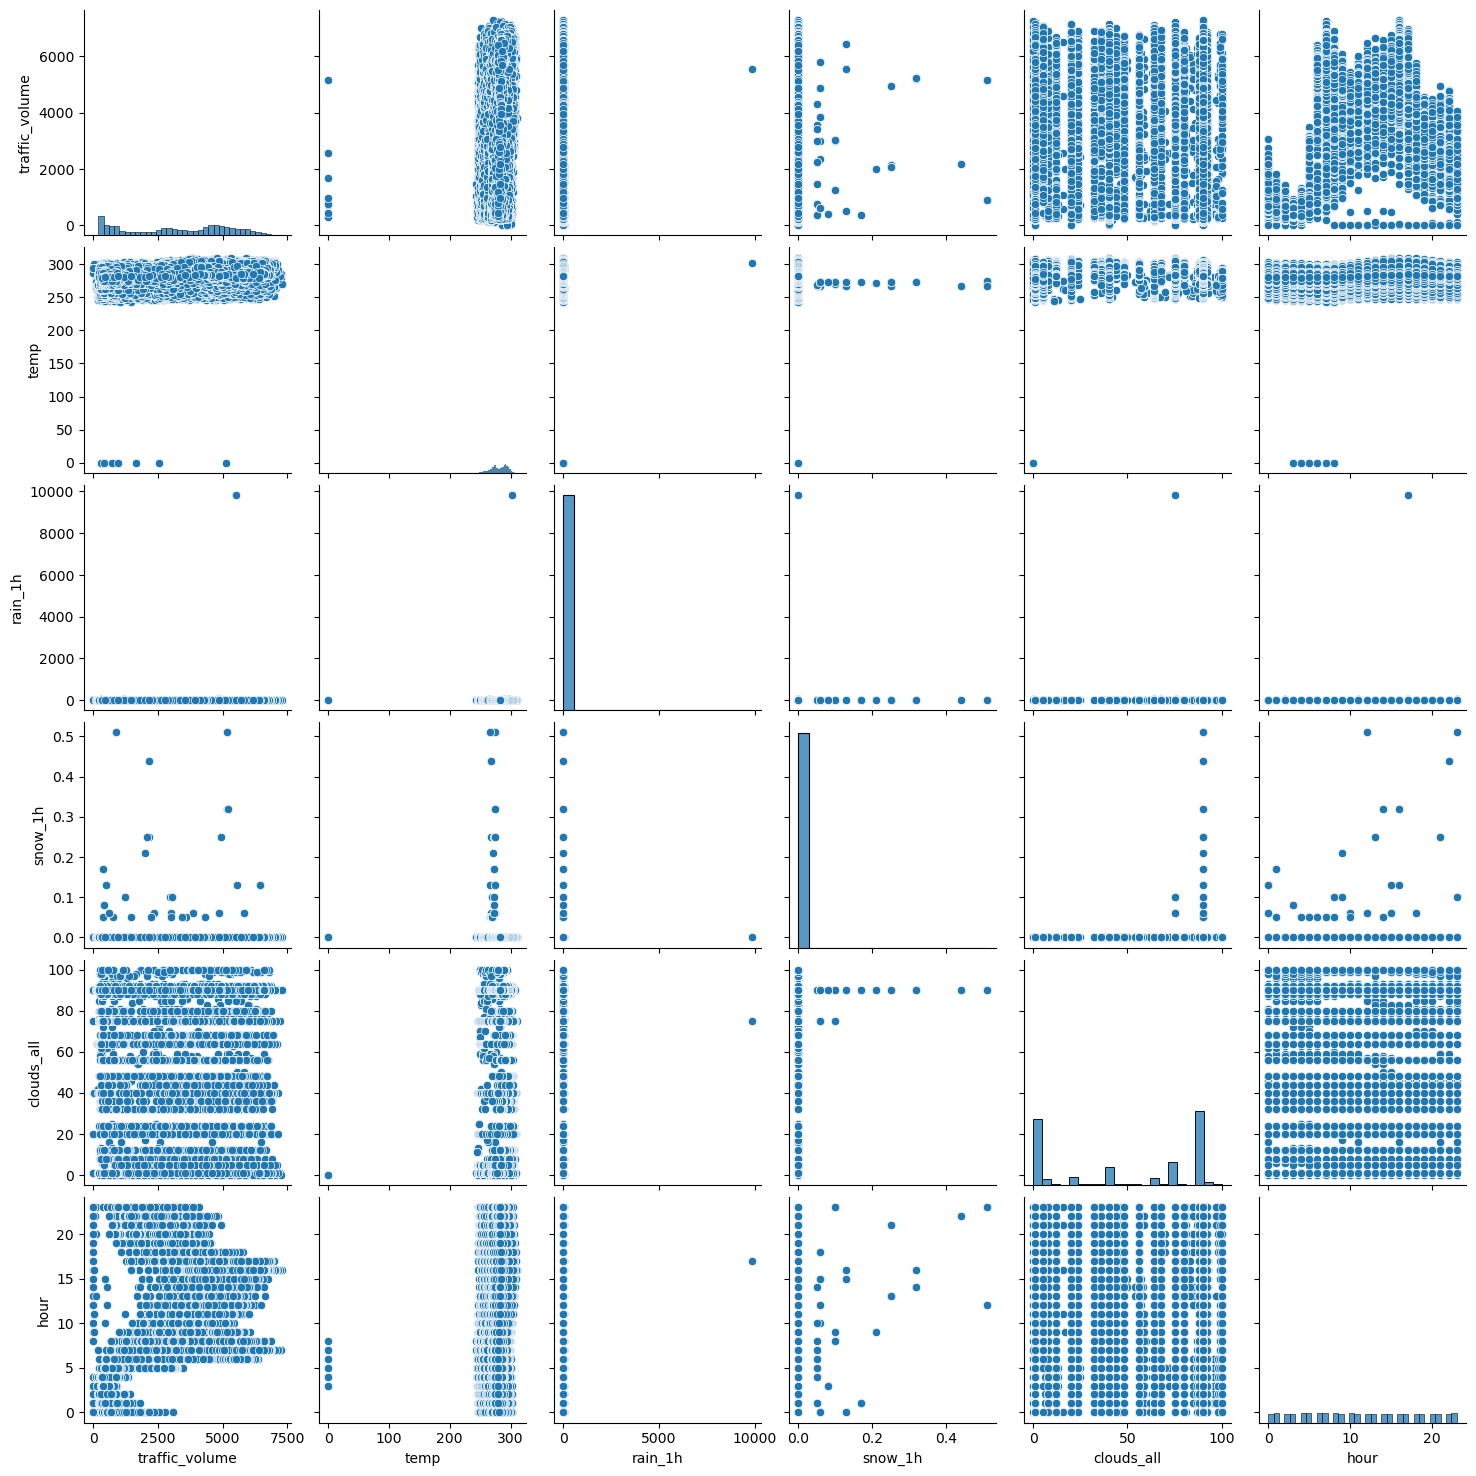

In [15]:
import seaborn as sns
sns.pairplot(features)

# Scaling

In [16]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
scaled_data=scaler.fit_transform(features)

# K-Means

In [17]:
from sklearn.cluster import KMeans
kmeans=KMeans(n_clusters=3,random_state=42)
df['kmeans']=kmeans.fit_predict(scaled_data)

In [18]:
df['kmeans'].value_counts()

kmeans
2    19251
0    15430
1    13523
Name: count, dtype: int64

In [19]:
kmeans.labels_

array([0, 2, 2, ..., 2, 2, 2], dtype=int32)

In [20]:
kmeans.cluster_centers_

array([[ 0.48135175,  0.32677342,  0.00776971, -0.02722834, -0.97627343,
         0.49587454],
       [-1.22359801, -0.21367766, -0.00396861, -0.0134613 , -0.13439017,
        -1.21122141],
       [ 0.47327738, -0.11159105, -0.00343351,  0.03123494,  0.87558241,
         0.45297148]])

# Visualizing clusters

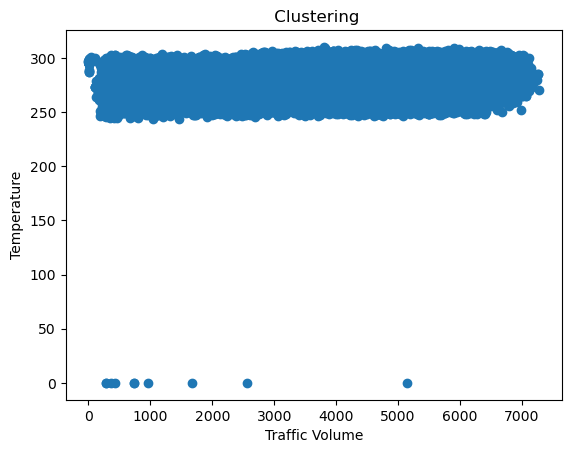

In [21]:
import matplotlib.pyplot as plt
plt.scatter(df['traffic_volume'], df['temp'])
plt.xlabel("Traffic Volume")
plt.ylabel("Temperature")
plt.title(" Clustering")
plt.show()

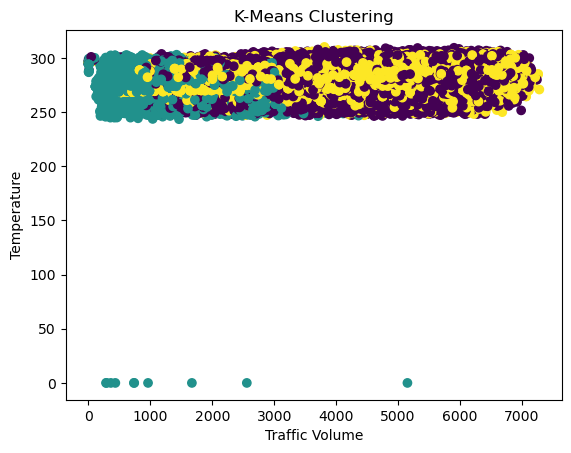

In [22]:
plt.scatter(df['traffic_volume'], df['temp'], c=df['kmeans'])
plt.xlabel("Traffic Volume")
plt.ylabel("Temperature")
plt.title("K-Means Clustering")
plt.show()

# Interpreting clusters

In [23]:
df.groupby('kmeans')[['traffic_volume','temp']].mean()

,traffic_volume,temp
kmeans,,
0,4215.957809,285.552600
1,829.347482,278.355055
2,4200.757831,279.724469


In [24]:
def label_cluster(x):
    if x == 0:
        return "Low Traffic"
    elif x == 1:
        return "Medium Traffic"
    else:
        return "High Traffic"

df['traffic_type'] = df['kmeans'].apply(label_cluster)

In [25]:
df['traffic_type'].value_counts()

traffic_type
High Traffic      19251
Low Traffic       15430
Medium Traffic    13523
Name: count, dtype: int64

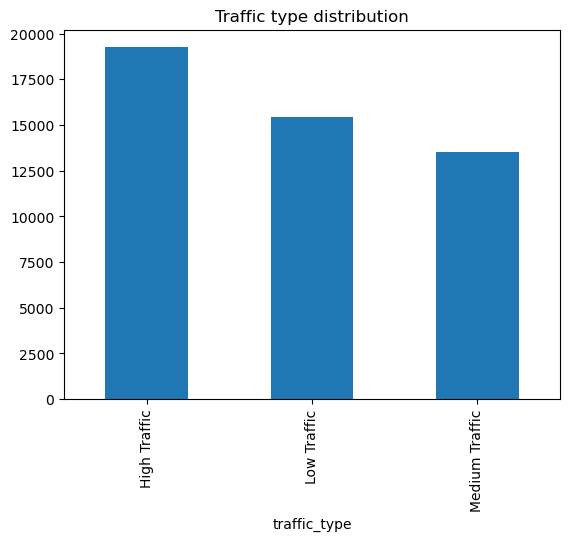

In [26]:
df['traffic_type'].value_counts().plot(kind='bar')
plt.title("Traffic type distribution")
plt.show()

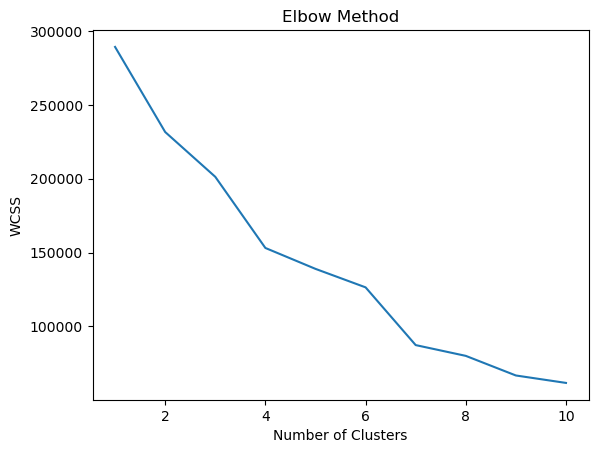

In [27]:
from sklearn.cluster import KMeans
wcss=[]
for i in range(1,11):
    kmeans=KMeans(n_clusters=i,random_state=42)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)
plt.plot(range(1,11),wcss)
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show() 

In [28]:
!pip install kneed

In [29]:
from kneed import KneeLocator   # correct library name
kl = KneeLocator(range(1,len(wcss)+1), wcss, curve='convex', direction='decreasing')
print(kl.elbow)

7


In [30]:
label=kmeans.labels_
label
from sklearn.metrics import silhouette_score
score=silhouette_score(scaled_data,label)
score

0.3325790963735791

# Hierarchical clustring

In [31]:
!pip install scipy

# Dendogram

In [32]:
sample_data = scaled_data[:1000]   # take first 1000 rows

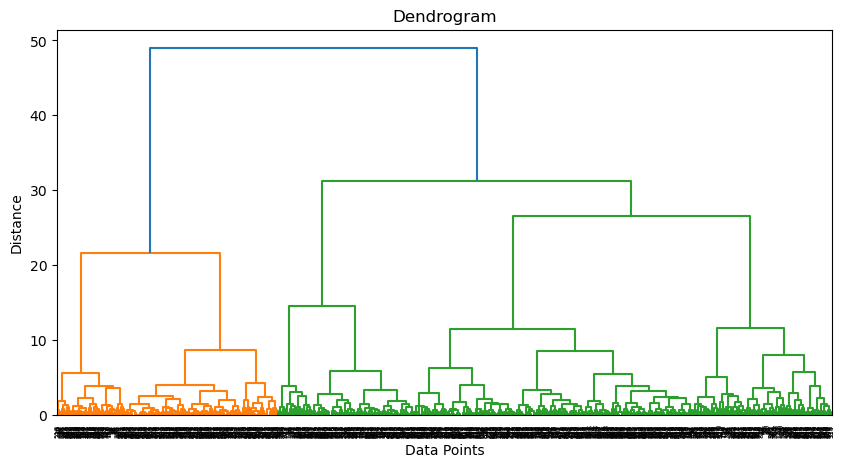

In [33]:
import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
sch.dendrogram(sch.linkage(sample_data,method='ward')) # ward to minimize the variance eithin clusters # minimum increse in varanice based on that they are merged
plt.title('Dendrogram')
plt.xlabel('Data Points')
plt.ylabel('Distance')
plt.show() 

# Applying hierarchical clustering

In [34]:
from sklearn.cluster import AgglomerativeClustering
hc=AgglomerativeClustering(n_clusters=3)
df['hc']=hc.fit_predict(scaled_data)

In [35]:
df['hc'].value_counts()

hc
0    33796
1    14407
2        1
Name: count, dtype: int64

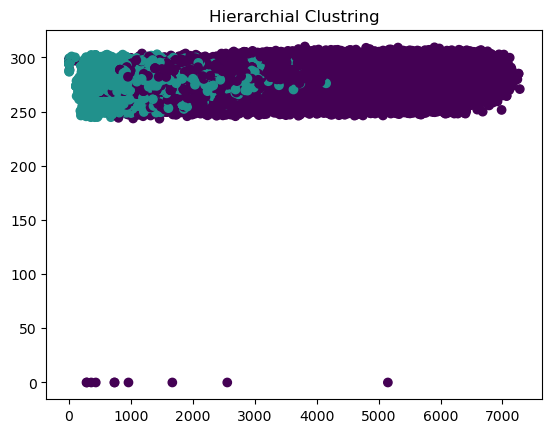

In [36]:
plt.scatter(df['traffic_volume'],df['temp'],c=df['hc'])
plt.title('Hierarchial Clustring')
plt.show()

In [37]:
df.groupby('hc')['traffic_volume'].mean()

hc
0    4239.390253
1     961.776636
2    5535.000000
Name: traffic_volume, dtype: float64

 # Evaluating clusters

In [38]:
from sklearn.metrics import silhouette_score
score_hc=silhouette_score(scaled_data,df['hc'])
print(score_hc)

0.306770215406368


# DBSCAN

In [39]:
from sklearn.cluster import DBSCAN
db=DBSCAN(eps=0.6,min_samples=5)
df['dbscan']=db.fit_predict(scaled_data)

# Identifying anomalies

In [40]:
df['dbscan'].value_counts()

dbscan
 0    48101
-1       64
 4       21
 1        8
 2        5
 3        5
Name: count, dtype: int64

# Analyzing anomalies

In [41]:
anomalies=df[df['dbscan']==-1]
anomalies.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume,hour,day,kmeans,traffic_type,hc,dbscan
1827,1,273.62,0.00,0.0,54,Clouds,broken clouds,2012-12-09 13:00:00,1686,13,6,2,High Traffic,0,-1
1828,1,273.62,0.00,0.0,54,Clouds,broken clouds,2012-12-09 14:00:00,1715,14,6,2,High Traffic,0,-1
7179,1,295.82,44.45,0.0,76,Rain,very heavy rain,2013-06-24 11:00:00,4802,11,0,2,High Traffic,0,-1
7771,1,298.96,0.00,0.0,64,Clouds,broken clouds,2013-07-19 00:00:00,3050,0,4,1,Medium Traffic,1,-1
8247,1,289.10,55.63,0.0,68,Rain,very heavy rain,2013-08-07 02:00:00,315,2,2,1,Medium Traffic,1,-1


# Visualizing anomalies

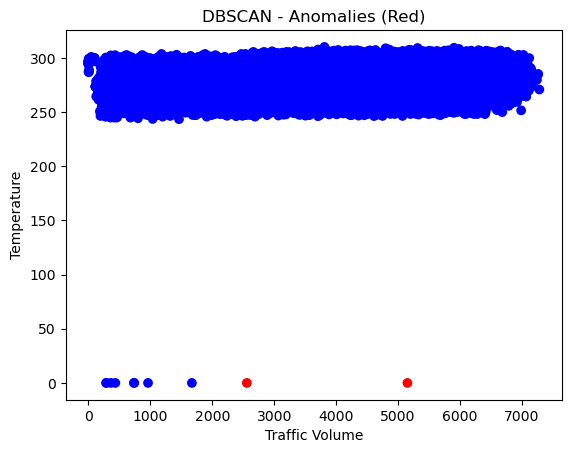

In [42]:
import numpy as np
colors = np.where(df['dbscan'] == -1, 'red', 'blue')
plt.scatter(df['traffic_volume'], df['temp'], c=colors)
plt.title("DBSCAN - Anomalies (Red)")
plt.xlabel("Traffic Volume")
plt.ylabel("Temperature")
plt.show()

In [43]:
anomalies[['traffic_volume','hour']].head()

,traffic_volume,hour
1827,1686,13
1828,1715,14
7179,4802,11
7771,3050,0
8247,315,2


# Tuning eps parameter

# PCA

In [44]:
from sklearn.decomposition import PCA
pca=PCA(n_components=2)
pca_data=pca.fit_transform(scaled_data)

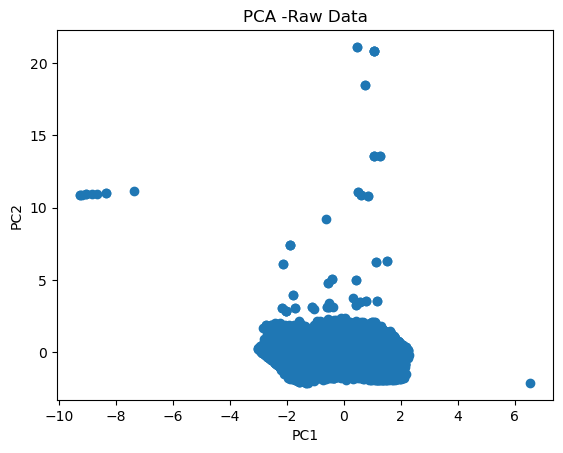

In [45]:
import matplotlib.pyplot as plt
plt.scatter(pca_data[:,0],pca_data[:,-1])
plt.title('PCA -Raw Data')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

# Visualizing clusters with PCA

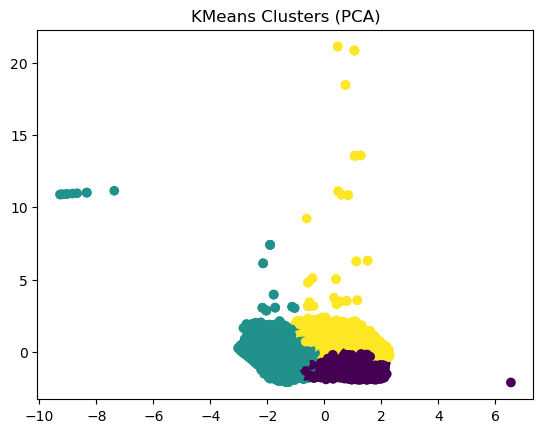

In [46]:
plt.scatter(pca_data[:,0],pca_data[:,-1],c=df['kmeans'])
plt.title('KMeans Clusters (PCA)')
plt.show()

# Visualizing anomalies with PCA

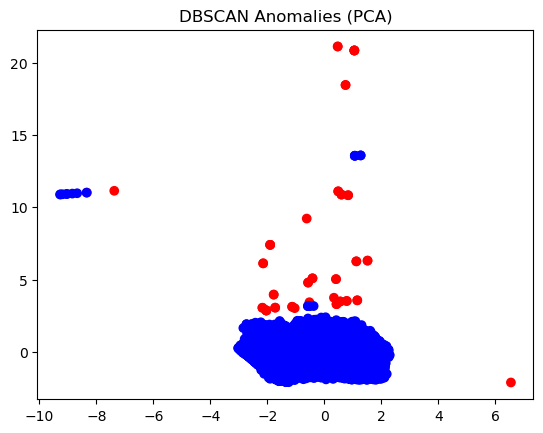

In [47]:
import numpy as np
colors=np.where(df['dbscan']==-1,'red','blue')
plt.scatter(pca_data[:,0],pca_data[:,-1],c=colors)
plt.title('DBSCAN Anomalies (PCA)')
plt.show()

In [48]:
print(pca.explained_variance_ratio_)

[0.23776178 0.18417594]


# T-SNE

In [49]:
from sklearn.manifold import TSNE
tsne=TSNE(n_components=2,random_state=42,perplexity=30)
tsne_data=tsne.fit_transform(scaled_data)

# Visualizing t-SNE

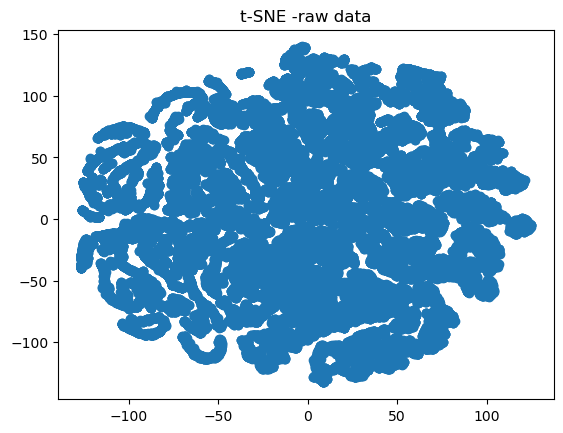

In [50]:
import matplotlib.pyplot as plt
plt.scatter(tsne_data[:,0],tsne_data[:,-1])
plt.title('t-SNE -raw data')
plt.show()

# Highlighting anomalies in t-SNE

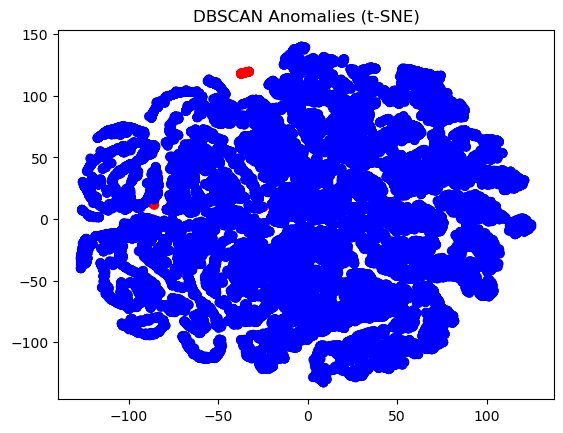

In [51]:
import numpy as np

colors = np.where(df['dbscan'] == -1, 'red', 'blue')

plt.scatter(tsne_data[:,0], tsne_data[:,1], c=colors)
plt.title("DBSCAN Anomalies (t-SNE)")
plt.show()

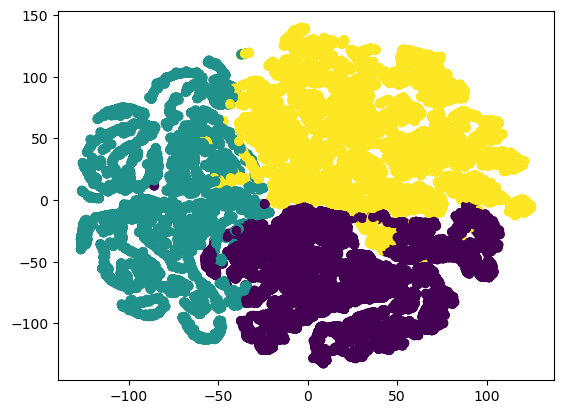

In [52]:
from sklearn.manifold import TSNE
tsne = TSNE(n_components=2, perplexity=30)
tsne_data = tsne.fit_transform(scaled_data)

plt.scatter(tsne_data[:,0], tsne_data[:,1], c=df['kmeans'])